# Whisky-Cask -- are whisky casks the alternative asset they're sold as?
### The 'whisky beat every other luxury asset' pitch, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

Scroll any wealth magazine and you'll meet the pitch: **rare whisky casks** are the alternative asset that *quietly beat the stock market* through the 2010s -- higher returns, lower volatility, and uncorrelated to equities, so they 'smooth your portfolio'. Cask-broker ads quote eye-watering index gains. This notebook asks the only question that matters: is that smoothness a feature of the **asset**, or an artifact of how the **index is measured**?

> **This is the plain-language layer.** Want the Geltner unsmoothing, the HAC t-test, and the cost-wedge arithmetic? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from whisky_cask import data, strategy as st

def _have_cache():
    try:
        data.fetch_gspc_annual()   # cache-only (fetch=False) by default
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("S&P (^GSPC) cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=16, year_start=2009, year_end=2024,
    whisky_ann=12.17, sp_ann=12.42,
    whisky_vol=10.21, sp_vol=13.92,
    whisky_sharpe=1.04, sp_sharpe=0.811,
    corr=-0.172, whisky_beats_frac=0.562,
    rho_lag1=0.779,
    raw_vol_pct=10.21, unsmoothed_vol_pct=29.13, vol_inflation_x=2.85,
    raw_sharpe=1.04, unsmoothed_sharpe=0.251,
    gross_ann_pct=12.17, net_ann_pct=5.93, total_cost_wedge_pct=6.24,
    mean_excess_pct=-0.67, hac_t=-0.148, win_frac=0.562,
)


S&P (^GSPC) cache present: True


## The answer first

| Question | Answer |
|---|---|
| Did the whisky index beat the S&P? | **No.** ~**12.2%/yr** vs the S&P's ~**12.4%/yr** (price-only) -- a dead heat, before whisky's costs. |
| Is whisky really 'low volatility'? | **No.** The headline 10% vol is a *measurement illusion*. Unsmoothed, the true vol is ~**29%** -- nearly 3x larger, and higher than equities. |
| Is the high Sharpe real? | **No.** Raw Sharpe **1.04** collapses to **0.25** once the appraisal-smoothing is removed -- worse than just owning the index fund. |
| Could a retail buyer earn the index? | **No.** Dealer markups, storage, insurance and evaporation cut ~**12%/yr gross to ~6%/yr net**. There is no tradable cask ETF. |

> The whisky-cask 'edge' is two illusions stacked on top of each other: an index that *looks* smooth because it's appraised once a year, and a gross return you can't actually capture once the middlemen are paid.

## 1 - The claim

> *"Rare whisky was the best-performing luxury collectible of the decade -- up hundreds of percent -- with lower volatility than stocks and almost no correlation to equity markets. A cask is a tangible, appreciating, uncorrelated asset."*

The numbers come from **appraisal-based indices** -- Knight Frank's Luxury Investment Index (rare whisky sub-index) and Rare Whisky 101's Apex 1000. These are published **once a year**, based on auction-hammer and valuation marks for a basket of the rarest *bottles*. That annual, smoothed cadence is the entire story.

## 2 - So what?

If a cask really delivered equity-beating returns at half the volatility and zero correlation, it would be one of the best risk-adjusted assets on earth -- and every pension fund would own a warehouse of it. The fun question is *why the index looks that good*, and whether a normal buyer could ever touch those returns. The answer is a clinic in two classic alt-asset traps: **appraisal smoothing** and **the cost wedge**.

## 3 - How would we even know?

Three traps to avoid:

1. **The smoothing illusion.** An index marked once a year, anchored to last year's mark, *cannot* show its true bumpiness. It reports a low volatility that the asset doesn't really have -- which flatters the Sharpe ratio. We'll un-smooth it.
2. **The cost wedge.** The index is what a *seller of rare bottles* realises. A cask buyer pays a dealer markup to get in, storage + insurance every year, loses ~2%/yr of spirit to evaporation (the 'Angels' Share'), and pays commission to get out.
3. **Tiny n.** We have ~16 annual observations (2009-2024). That is nowhere near enough to certify any 'edge' as statistically real, even if one existed.

We test all of this against the S&P 500 (^GSPC) calendar-year price returns from 2009 to 2024 -- the same window, apples to apples (both price-only).

## 4 - The teardown -- let's actually look

**First, meet the data:** the hardcoded annual whisky index in this study's `data.py`, paired with the S&P 500 calendar-year return.

In [2]:
wh = data.whisky_index()
if HAVE_REAL:
    df = data.fetch_gspc_annual()
    perf = st.performance_stats(df)
    whisky_ann, sp_ann = perf['whisky_ann'], perf['sp_ann']
    corr = perf['corr']
else:
    whisky_ann, sp_ann, corr = R['whisky_ann'], R['sp_ann'], R['corr']

print('Whisky index years:', int(wh['year'].min()), '-', int(wh['year'].max()))
print(f'Whisky annualised: {whisky_ann:.1f}%/yr  |  S&P annualised: {sp_ann:.1f}%/yr')
print(f'Correlation to S&P: {corr:+.2f}  (the pitch sells this as diversification)')
print()
print('Both are PRICE-ONLY: the whisky index has no yield, so we strip S&P dividends')
print('to keep the comparison fair. (Total-return S&P would win outright.)')

Whisky index years: 2008 - 2024
Whisky annualised: 12.2%/yr  |  S&P annualised: 12.4%/yr
Correlation to S&P: -0.17  (the pitch sells this as diversification)

Both are PRICE-ONLY: the whisky index has no yield, so we strip S&P dividends
to keep the comparison fair. (Total-return S&P would win outright.)


**The boom -- and the hangover.**

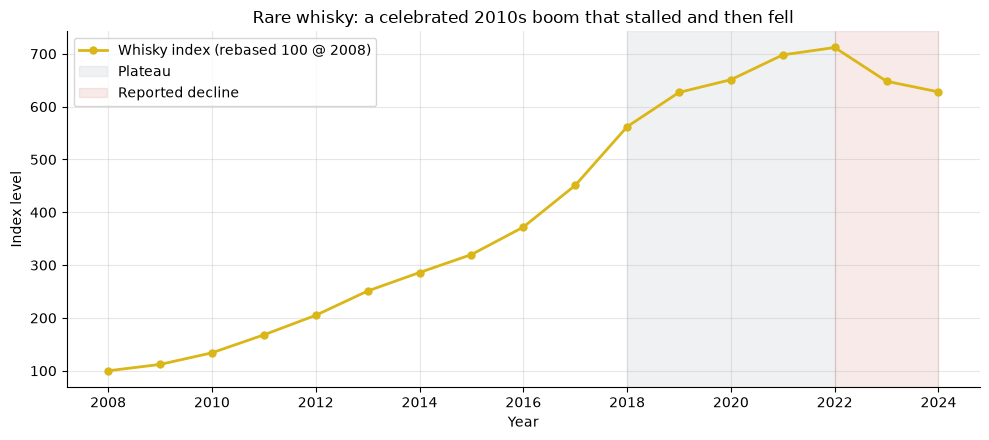

Peak: 712 in 2022
Latest: 628 in 2024 (-11.8% from peak)


In [3]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(wh['year'], wh['index_level'], 'o-', c=AMBER, lw=2, ms=5,
        label='Whisky index (rebased 100 @ 2008)')
ax.axvspan(2018, 2022, color=GREY, alpha=0.12, label='Plateau')
ax.axvspan(2022, 2024, color=RED, alpha=0.10, label='Reported decline')
ax.set_xlabel('Year'); ax.set_ylabel('Index level')
ax.set_title('Rare whisky: a celebrated 2010s boom that stalled and then fell')
ax.legend(); plt.tight_layout(); plt.show()
peak = wh.loc[wh['index_level'].idxmax()]
last = wh.iloc[-1]
print(f'Peak: {peak["index_level"]:.0f} in {int(peak["year"])}')
print(f'Latest: {last["index_level"]:.0f} in {int(last["year"])} '
      f'({(last["index_level"]/peak["index_level"]-1)*100:+.1f}% from peak)')

The index roughly **6x'd from 2008 to its peak** -- the number the cask-broker ads quote. But the secondary market cooled hard after 2021, and the appraisal indices finally printed *negative* years in 2023-2024 as the cask-investment bubble deflated (amid a wave of FCA and advertising-standards warnings about cask mis-selling).

**The smoothness illusion -- reported vs unsmoothed volatility.**

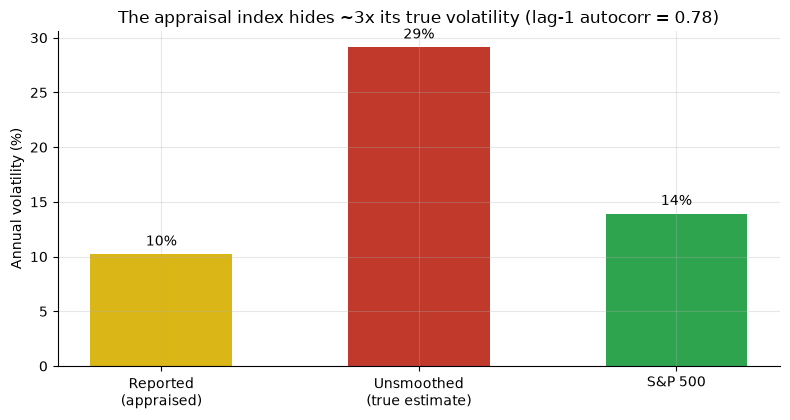

Reported vol: 10.2%  ->  unsmoothed vol: 29.1%  (2.9x larger)
A once-a-year appraisal mark cannot show the asset bouncing around. The low
reported vol is a property of the MEASUREMENT, not of the whisky.


In [4]:
if HAVE_REAL:
    sm = st.smoothing_stats(df)
    raw_vol, true_vol = sm['raw_vol_pct'], sm['unsmoothed_vol_pct']
    rho = sm['rho_lag1']
else:
    raw_vol, true_vol, rho = R['raw_vol_pct'], R['unsmoothed_vol_pct'], R['rho_lag1']

fig, ax = plt.subplots(figsize=(8.0, 4.3))
bars = ax.bar(['Reported\n(appraised)', 'Unsmoothed\n(true estimate)',
               'S&P 500'],
              [raw_vol, true_vol, R['sp_vol']],
              color=[AMBER, RED, GREEN], width=0.55)
ax.set_ylabel('Annual volatility (%)')
ax.set_title(f'The appraisal index hides ~3x its true volatility (lag-1 autocorr = {rho:.2f})')
for b, v in zip(bars, [raw_vol, true_vol, R['sp_vol']]):
    ax.annotate(f'{v:.0f}%', (b.get_x()+b.get_width()/2, v+0.5),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Reported vol: {raw_vol:.1f}%  ->  unsmoothed vol: {true_vol:.1f}%  '
      f'({true_vol/raw_vol:.1f}x larger)')
print('A once-a-year appraisal mark cannot show the asset bouncing around. The low')
print('reported vol is a property of the MEASUREMENT, not of the whisky.')

The reported index has a lag-1 autocorrelation of **0.78** -- last year's mark powerfully anchors this year's. That is the textbook fingerprint of an appraisal-based series. Undo it (the standard Geltner unsmoothing) and the 'true' volatility jumps from ~10% to ~**29%** -- *higher* than the S&P. The 'low-vol alternative asset' is, once measured honestly, more volatile than the stock market.

## 5 - The verdict

- **Signal -- None.** The whisky index does **not** beat the S&P: ~12.2% vs ~12.4%/yr, a mean annual *excess* of **-0.7pp** with a HAC t of **-0.15**. The seductive high Sharpe (1.04) is a smoothing artifact -- it collapses to **0.25** once the index is unsmoothed. n=16 could not certify an edge even if one existed.
- **Tradability -- Mirage.** There is no cask ETF. A real buyer pays a dealer markup to enter, storage + insurance + evaporation every year, and commission to exit -- cutting ~12%/yr gross to ~**6%/yr net**. The index return is unreachable.
- **Busted.** The 'uncorrelated, low-vol, equity-beating' story is three claims, and all three fail: the low vol is measurement smoothing, the high return doesn't beat equities, and the negative correlation is the random sign of 16 noisy points.

## 6 - Could you actually trade it?

The 'strategy' is to buy a cask, hold it in a bonded warehouse, and sell it later. The index never charges the costs a real owner pays:

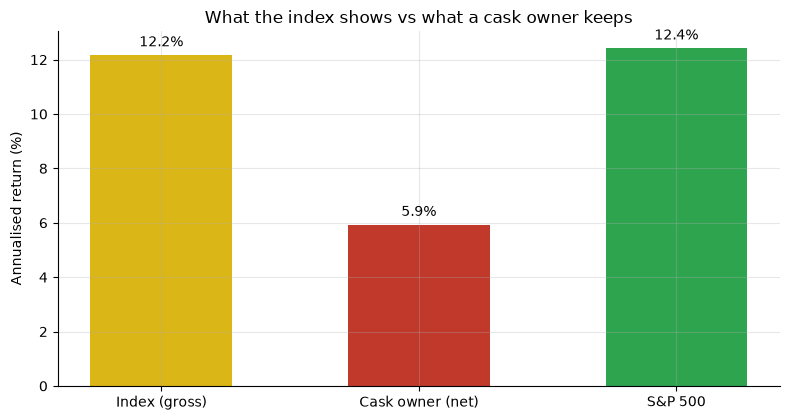

Index gross: 12.2%/yr  ->  net of real costs: 5.9%/yr
Cost wedge: 6.2pp/yr eaten by markup, storage, insurance, evaporation.
The index is a sellers-of-rare-bottles benchmark. You are not that seller.


In [5]:
if HAVE_REAL:
    cost = st.net_of_costs(df)
    gross, net = cost['gross_ann_pct'], cost['net_ann_pct']
else:
    gross, net = R['gross_ann_pct'], R['net_ann_pct']

fig, ax = plt.subplots(figsize=(8.0, 4.3))
bars = ax.bar(['Index (gross)', 'Cask owner (net)', 'S&P 500'],
              [gross, net, R['sp_ann']], color=[AMBER, RED, GREEN], width=0.55)
ax.set_ylabel('Annualised return (%)')
ax.set_title('What the index shows vs what a cask owner keeps')
for b, v in zip(bars, [gross, net, R['sp_ann']]):
    ax.annotate(f'{v:.1f}%', (b.get_x()+b.get_width()/2, v+0.2),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Index gross: {gross:.1f}%/yr  ->  net of real costs: {net:.1f}%/yr')
print(f'Cost wedge: {gross-net:.1f}pp/yr eaten by markup, storage, insurance, evaporation.')
print('The index is a sellers-of-rare-bottles benchmark. You are not that seller.')

Once you subtract the ~40% dealer markup (amortised), ~1.5%/yr storage and insurance, ~2%/yr evaporation, and the exit commission, the headline ~12%/yr gross becomes ~**6%/yr net** -- roughly *half* the index, and well behind a total-return index fund. And that assumes your individual cask tracks the index of the rarest bottles, which most do not.

## 7 - Going further

- **The positive control:** the companion notebook plants smoothing into a synthetic alt-asset and shows the Sharpe inflate exactly the way the real index's does -- the machinery is honest.
- **Same family:** every appraisal-based 'alternative asset' shares this flaw -- fine art, farmland, private real estate. The Geltner unsmoothing is the universal lie detector.

*Think casks really are the alt-asset of the decade? Fork this, plug in a genuinely transaction-based (not appraisal) cask price series, net out the real costs, and show an unsmoothed Sharpe that beats a total-return index fund. That's the bar.*